# Heart Disease Prediction using Machine Learning

This notebook builds a binary classifier that predicts whether a patient is likely to have heart disease, based on 11 clinical and demographic features (age, sex, chest pain type, resting blood pressure, cholesterol, fasting blood sugar, resting ECG results, max heart rate, exercise-induced angina, ST depression, and ST slope).

**Workflow:** Data Cleaning → EDA → Feature Engineering → Train-Test Split → Basic Models (Logistic Regression, Decision Tree, KNN) → Advanced Models (Random Forest, XGBoost) → Hyperparameter Tuning → Model Evaluation → Best Model Selection → Save Model.

## Dataset Loading

Loading the raw dataset and taking a first look at its structure.

In [51]:
import pandas as pd

df = pd.read_csv("heart.csv")

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [52]:
print("Shape:", df.shape)
df.info()

Shape: (918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [53]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Data Cleaning

Checking for missing values and duplicate rows before any further processing, since both can distort statistics and model training if left unhandled.

In [54]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [55]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


`Cholesterol` and `RestingBP` use `0` to represent missing readings (not an actual physiological value), so those are replaced with the median rather than left as 0, which would otherwise distort the model.

In [56]:
df = df.drop_duplicates()

df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Exploratory Data Analysis (EDA)

Visualizing the cleaned data to check class balance, look at key distributions, and spot early relationships between features and the target before modeling.

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

Target class balance — confirms whether the dataset is roughly balanced between disease/no-disease cases, which affects how evaluation metrics should be read:

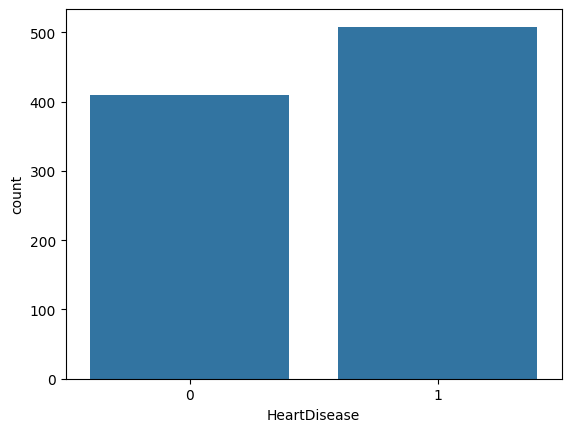

In [58]:
sns.countplot(x='HeartDisease', data=df)
plt.show()

Age distribution:

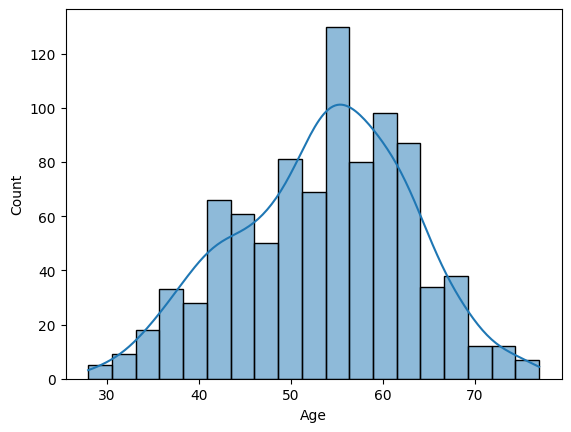

In [59]:
sns.histplot(df['Age'], kde=True)
plt.show()

Cholesterol distribution, after the zero-value cleanup above:

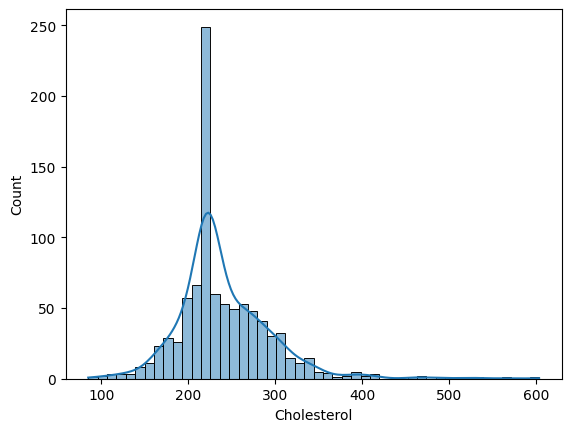

In [60]:
sns.histplot(df['Cholesterol'], kde=True)
plt.show()

Checking for remaining outliers in cholesterol:

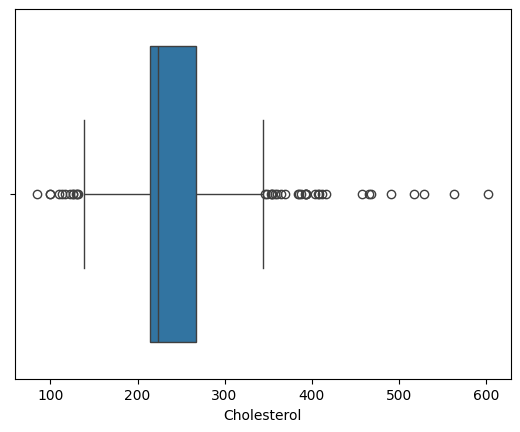

In [61]:
sns.boxplot(x=df['Cholesterol'])
plt.show()

Correlation heatmap of the numeric features, as a first look at which raw variables move together with `HeartDisease`:

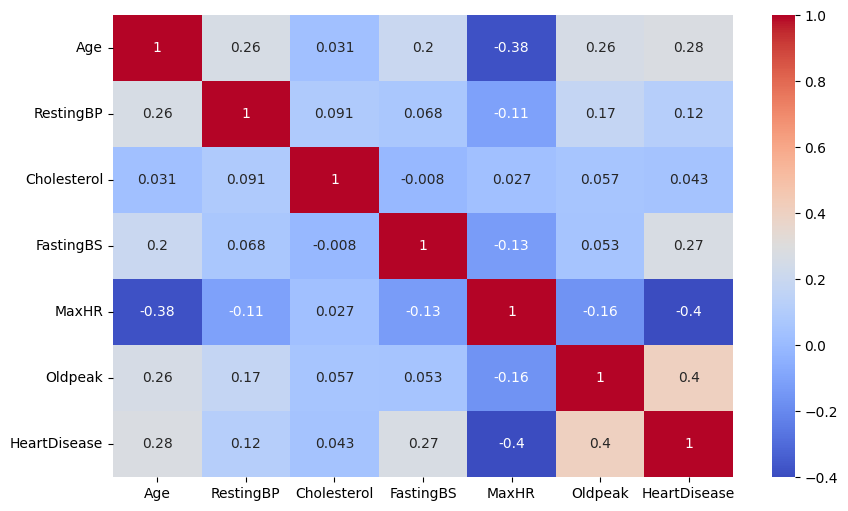

In [62]:
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

## Feature Engineering

The categorical columns (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`) are one-hot encoded with `drop_first=True` so the model can use them numerically, without implying a false order between categories.

In [63]:
df_encode = pd.get_dummies(df, drop_first=True)

print(df_encode.shape)
df_encode.head()

(918, 16)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [64]:
X = df_encode.drop('HeartDisease', axis=1)
y = df_encode['HeartDisease']

feature_columns = X.columns.tolist()

print(X.shape)
print(y.shape)

(918, 15)
(918,)


## Train-Test Split

`stratify=y` keeps the same proportion of heart-disease/no-disease cases in both the train and test sets — important so the test score isn't skewed by an unlucky split.

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(734, 15)
(184, 15)


### Feature Scaling

The scaler is fit only on `X_train`, then applied to `X_test` with `transform` (not `fit_transform`). Fitting on the full dataset before splitting would let information from the test set leak into the scaling, making the test score look better than the model would actually perform on truly unseen data.

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(734, 15)
(184, 15)


## Logistic Regression

A linear baseline model, trained first since it's fast and interpretable. Establishing this baseline makes it possible to check whether the more complex models below are actually worth their added complexity.

In [67]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

## Decision Tree

A single decision tree — tests whether a simple, rule-based non-linear model beats the linear baseline.

In [68]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_train)

dt_pred = dt.predict(X_test_scaled)

## K-Nearest Neighbors

A distance-based classifier with no assumptions about the underlying data distribution. It relies on the feature scaling done above, since distances are meaningless if features are on very different scales.

In [69]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

## Random Forest

An ensemble of decision trees trained on bootstrapped samples, with predictions combined by majority vote — reduces the overfitting risk of a single decision tree.

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)

## XGBoost

A gradient-boosted tree ensemble that builds trees sequentially, each correcting the previous ones' errors. Usually one of the strongest performers on structured/tabular clinical data like this.

In [71]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

xgb.fit(X_train_scaled, y_train)

xgb_pred = xgb.predict(X_test_scaled)

## Hyperparameter Tuning

Each model is tuned with `GridSearchCV` using 5-fold stratified cross-validation, scored on ROC-AUC — a better fit than accuracy for a medical diagnosis target, since it measures how well the model separates the two classes across all thresholds, not just at the default 0.5 cutoff.

In [72]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Logistic Regression Tuning

In [74]:
log_param_grid = {'C': [0.01, 0.1, 1, 10]}

In [75]:
log_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    log_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

log_search.fit(X_train_scaled, y_train)

print(log_search.best_params_)

{'C': 0.1}


In [76]:
best_lr = log_search.best_estimator_
lr_pred = best_lr.predict(X_test_scaled)

### Decision Tree Tuning

In [77]:
dt_param_grid = {'max_depth': [3, 5, 7, None], 'min_samples_split': [2, 5, 10]}

In [78]:
dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

dt_search.fit(X_train_scaled, y_train)

print(dt_search.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [79]:
best_dt = dt_search.best_estimator_
dt_pred = best_dt.predict(X_test_scaled)

### KNN Tuning

In [80]:
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}

In [81]:
knn_search = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

knn_search.fit(X_train_scaled, y_train)

print(knn_search.best_params_)

{'n_neighbors': 11, 'weights': 'distance'}


In [82]:
best_knn = knn_search.best_estimator_
knn_pred = best_knn.predict(X_test_scaled)

### Random Forest Tuning

In [83]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

print(grid_rf.best_params_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [84]:
best_rf = grid_rf.best_estimator_
rf_pred = best_rf.predict(X_test_scaled)

### XGBoost Tuning

In [85]:
xgb_param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2]}

In [86]:
xgb_search = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

xgb_search.fit(X_train_scaled, y_train)

print(xgb_search.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


In [87]:
best_xgb = xgb_search.best_estimator_
xgb_pred = best_xgb.predict(X_test_scaled)

## Model Evaluation

Per-model accuracy and a full classification report (precision, recall, F1 for both classes) for each of the five tuned models, as a first individual look before comparing them side by side.

In [88]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve

In [89]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8858695652173914
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



In [90]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7608695652173914
              precision    recall  f1-score   support

           0       0.72      0.77      0.74        82
           1       0.80      0.75      0.78       102

    accuracy                           0.76       184
   macro avg       0.76      0.76      0.76       184
weighted avg       0.76      0.76      0.76       184



In [91]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN Accuracy: 0.8804347826086957
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        82
           1       0.89      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



In [92]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8586956521739131
              precision    recall  f1-score   support

           0       0.83      0.85      0.84        82
           1       0.88      0.86      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [93]:
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.8858695652173914
              precision    recall  f1-score   support

           0       0.87      0.88      0.87        82
           1       0.90      0.89      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.88       184
weighted avg       0.89      0.89      0.89       184



### Full Comparison Table

Accuracy, Precision, Recall, F1, and ROC-AUC side by side for all five tuned models — Recall and ROC-AUC matter most here, since missing an actual heart disease case (a false negative) is the costliest type of error a screening model can make.

In [94]:
models = {
    'Logistic Regression': best_lr,
    'Decision Tree': best_dt,
    'KNN': best_knn,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

In [95]:
results = []
for name, m in models.items():
    pred = m.predict(X_test_scaled)
    proba = m.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,KNN,0.880435,0.892157,0.892157,0.892157,0.942193
4,XGBoost,0.885870,0.900990,0.892157,0.896552,0.936155
0,Logistic Regression,0.885870,0.885714,0.911765,0.898551,0.931612
3,Random Forest,0.858696,0.880000,0.862745,0.871287,0.925753
1,Decision Tree,0.760870,0.802083,0.754902,0.777778,0.842719


### ROC Curves

Plots the true positive rate against the false positive rate at every possible decision threshold for each model — a curve that bows further toward the top-left corner indicates better separation between the two classes, independent of which threshold is eventually used.

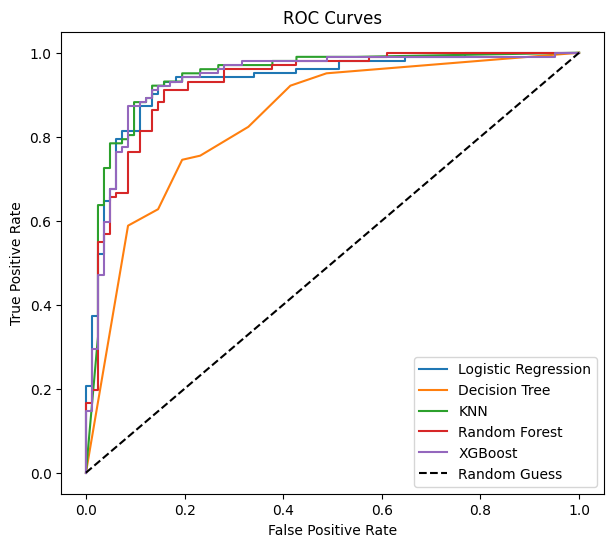

In [96]:
plt.figure(figsize=(7,6))
for name, m in models.items():
    proba = m.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

## Best Model Selection

The model with the highest ROC-AUC in the comparison table is selected automatically — no hardcoded model name — so this still picks the right model even if the ranking changes after re-running with different data or random seeds.

In [97]:
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
best_model = models[best_model_name]

best_model_name

'KNN'

Confusion matrix for the selected best model — shows exactly how many false negatives (missed disease cases) and false positives (healthy patients flagged as at-risk) it produces:

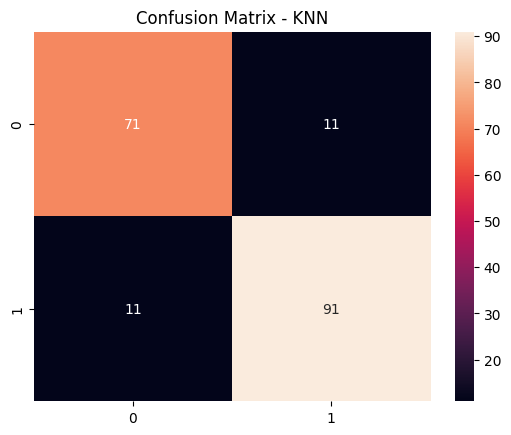

In [98]:
cm = confusion_matrix(y_test, best_model.predict(X_test_scaled))

sns.heatmap(cm, annot=True, fmt='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

### Feature Importance

Only meaningful for the tree-based models (Random Forest, XGBoost) — shows which inputs the model relies on most.

In [99]:
if best_model_name in ('Random Forest', 'XGBoost'):
    importances = pd.Series(best_model.feature_importances_, index=feature_columns)
    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(8,6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f'Feature Importance - {best_model_name}')
    plt.show()
else:
    print(f"{best_model_name} has no feature_importances_ attribute")

KNN has no feature_importances_ attribute


In [100]:
import pickle

pickle.dump(best_model, open('heart_disease_model.pkl','wb'))
pickle.dump(scaler, open('heart_scaler.pkl','wb'))
pickle.dump(feature_columns, open('heart_feature_columns.pkl','wb'))

print("Model Saved Successfully:", best_model_name)

Model Saved Successfully: KNN
